In [25]:
import numpy as np # Used for handling numerical arrays
import matplotlib.pyplot as plt # Standard tool for creating plots
import seaborn as sns # Built on top of matplotlib for prettier statistical plots

In [26]:
# X represents our 'Feature' (the data we use to make predictions)
X = np.array([1 , 3, 4, 6, 7]) # Years of experience

# y represents our 'Target' (the value we want our model to learn to predict)
y = np.array([15, 35, 45, 65, 75]) # Salary in thousands

In [27]:
def compute_cost(X,y,w,b):
    
    m = X.shape[0] # The number of training example
    cost = 0.0

    for i in  range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error_squared = error ** 2
        cost = cost + error_squared
    cost = cost /2 * m
    return cost
        

In [28]:
def make_prediction(X, y, w, b):
  """
  Calculates predictions using the linear regression formula: y = wx + b
  w: weight (slope)
  b: bias (intercept)
  """
  m = X.shape[0] # The number of training examples
  pred_list = np.zeros((m,)) # Create an empty array to store our results

  for i in range(m):
    # Calculate the prediction for each specific data point
    pred_list[i] = w * X[i] + b

  return pred_list

Predictions calculated by the model: [15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost:0.0')

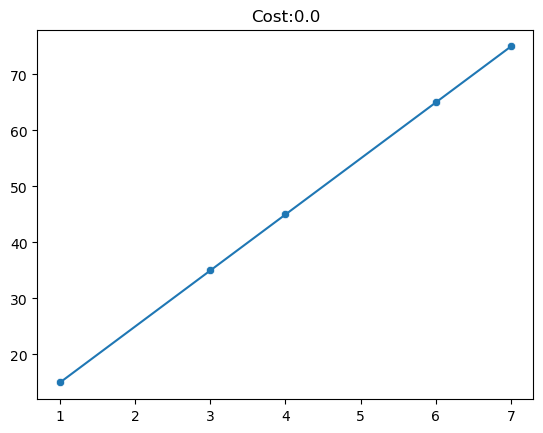

In [29]:

predictions = make_prediction(X, y, w=10, b=5)
print(f"Predictions calculated by the model: {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost:{compute_cost(X,y,w=10,b=5)}")

Text(0, 0.5, 'Cost')

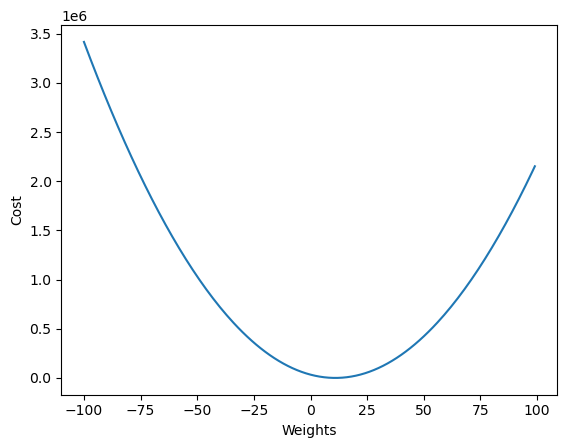

In [30]:
w=[]
cost=[]

for i in range(-100,100):
    cost_i = compute_cost(X,y,w=i,b=0)
    w.append(i)
    cost.append(cost_i)
plt.plot(w,cost)
plt.xlabel("Weights")
plt.ylabel("Cost")

In [31]:
def calculate_gradient(X,y,w,b):
    m = X.shape[0] # The number of training example
    dj_dw = 0.0
    dj_db = 0.0
    for i in  range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        
        dj_dw = dj_dw +(error*X[i])
        dj_db = dj_db + error
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw,dj_db

In [32]:
calculate_gradient(X,y,w=3,b=0)

(np.float64(-176.4), np.float64(-34.4))

## Gradient Descent Algorithm

In [43]:
def gradient_descent(X, y, w_input, b_input, max_iteration, alpha=0.01):
    w = w_input
    b = b_input

    cost_memo = []
    iteration  = []
    for i in range(max_iteration):
        dj_dw, dj_db = calculate_gradient(X,y,w,b)
        
        # Update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X,y,w,b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:
            print(f"iteration:{i}, w:{w:0.4f}, b:{b:0.4f}, dj_dw:{dj_dw:0.4f}, dj_db:{dj_db:0.4f}, Cost:{cost:0.4f}")

    return w,b,cost_memo,iteration

    

In [50]:
w_final,b_final,memo,iter = gradient_descent(X, y, w_input=0, b_input=0, max_iteration=10000, alpha=0.01)

iteration:0, w:2.4300, b:0.4700, dj_dw:-243.0000, dj_db:-47.0000, Cost:19759.2915
iteration:100, w:10.4659, b:2.5593, dj_dw:0.0926, dj_db:-0.4848, Cost:15.3002
iteration:200, w:10.3821, b:2.9986, dj_dw:0.0759, dj_db:-0.3976, Cost:10.2880
iteration:300, w:10.3133, b:3.3588, dj_dw:0.0622, dj_db:-0.3260, Cost:6.9178
iteration:400, w:10.2569, b:3.6542, dj_dw:0.0510, dj_db:-0.2673, Cost:4.6516
iteration:500, w:10.2107, b:3.8965, dj_dw:0.0418, dj_db:-0.2192, Cost:3.1278
iteration:600, w:10.1727, b:4.0951, dj_dw:0.0343, dj_db:-0.1798, Cost:2.1032
iteration:700, w:10.1416, b:4.2580, dj_dw:0.0281, dj_db:-0.1474, Cost:1.4142
iteration:800, w:10.1162, b:4.3915, dj_dw:0.0231, dj_db:-0.1209, Cost:0.9509
iteration:900, w:10.0952, b:4.5010, dj_dw:0.0189, dj_db:-0.0991, Cost:0.6394
iteration:1000, w:10.0781, b:4.5909, dj_dw:0.0155, dj_db:-0.0813, Cost:0.4299
iteration:1100, w:10.0640, b:4.6645, dj_dw:0.0127, dj_db:-0.0666, Cost:0.2891
iteration:1200, w:10.0525, b:4.7249, dj_dw:0.0104, dj_db:-0.0546, C

In [48]:
print(f"w :{w_final:0.4f}, b :{b_final:0.4f}")

w :10.0000, b :5.0000


Predictions calculated by the model: [14.99999999 35.         45.         65.         75.        ]


Text(0.5, 1.0, 'Cost:1.3252192339093643e-16')

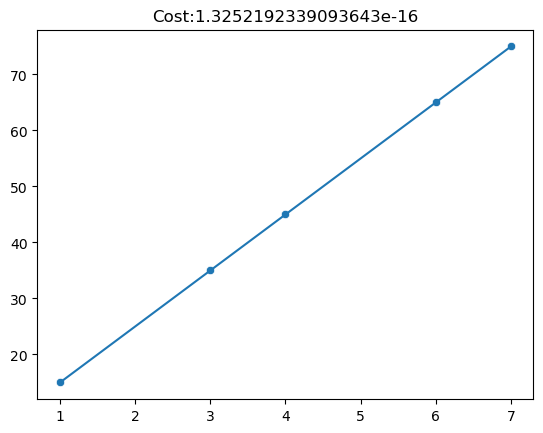

In [51]:
predictions = make_prediction(X, y, w=w_final, b=b_final)
print(f"Predictions calculated by the model: {predictions}")

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost:{compute_cost(X,y,w=w_final,b=b_final)}")

In [53]:
# jar 2 bosor er Expreince ase tar salary koto
prediction = w_final*2 + b_final
print(f"prediction:{prediction:0.4f}")

prediction:25.0000


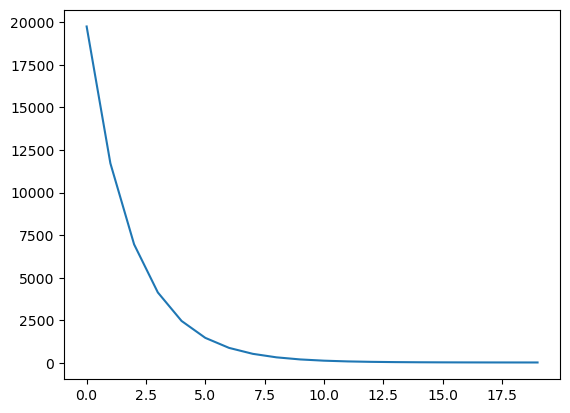

In [57]:
plt.plot(iter[:20],memo[:20])